# Data Analysis Report

#### Project Overview
This project analyzes historical bike rental data to predict daily rental demand using machine learning models. The objective was to understand demand patterns and build an accurate regression model.

#### Feature Engineering & Conversion
Several features required preprocessing before modeling:
- Date Feature:The original date column was converted into meaningful time-based features such as:
   - Year
   - Month
   - Day
   - Weekday
- This helped capture seasonal and weekly demand patterns.
- Categorical Variables Features like:
   - Season
   - Weather situation
   - Holiday
   - Working day
- were treated as categorical variables and encoded numerically (label encoding or one-hot encoding). This allowed machine learning models to interpret them properly.
- Scaling of Numerical Features Continuous variables such as:
   - Temperature
   - Humidity
   - Windspeed
- were standardized for models sensitive to scale (Linear Regression, Ridge, KNN).

#### Important Observation
- From exploratory analysis:
  - Temperature showed strong positive correlation with bike rentals.
  - Season significantly influenced demand (higher in summer and fall).
  - Working day vs Holiday impacted rental behavior.
  - Weather condition negatively affected demand during poor weather.
  - Humidity had a moderate negative relationship with rentals.
  - Windspeed had relatively lower impact compared to other features.
- The target variable (bike count) exhibited nonlinear relationships with several predictors, which explains why tree-based models performed better.

# Predictive Model

In [1]:
import pandas as pd
import numpy as np

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("hour.csv")

In [4]:
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [7]:
df.shape

(17379, 17)

In [8]:
df['cnt'].describe()                   #Description of Target Variable

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

In [9]:
df['season'].unique()

array([1, 2, 3, 4])

In [10]:
df['weathersit'].unique()

array([1, 2, 3, 4])

In [11]:
df['holiday'].unique()

array([0, 1])

In [12]:
df['workingday'].unique()

array([0, 1])

In [13]:
df['yr'].unique()

array([0, 1])

### Handling Null Values

In [14]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [15]:
#Therefore,no null values present.

In [16]:
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
def check_outliers_iqr(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    percentage = (outliers.shape[0] / df.shape[0]) * 100
    print(f"{column}")
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", outliers.shape[0])
    print(f"Outlier Percentage: {percentage:.2f}%")
    print("--------------------------------------------------")

In [17]:
for col in num_cols:
    check_outliers_iqr(col)

temp
Lower Bound: -0.13999999999999996
Upper Bound: 1.1400000000000001
Number of Outliers: 0
Outlier Percentage: 0.00%
--------------------------------------------------
atemp
Lower Bound: -0.09854999999999997
Upper Bound: 1.0530499999999998
Number of Outliers: 0
Outlier Percentage: 0.00%
--------------------------------------------------
hum
Lower Bound: 0.029999999999999916
Upper Bound: 1.23
Number of Outliers: 22
Outlier Percentage: 0.13%
--------------------------------------------------
windspeed
Lower Bound: -0.1193
Upper Bound: 0.4775
Number of Outliers: 342
Outlier Percentage: 1.97%
--------------------------------------------------
cnt
Lower Bound: -321.5
Upper Bound: 642.5
Number of Outliers: 505
Outlier Percentage: 2.91%
--------------------------------------------------


In [18]:
# Outliers Percentage are less than 3.So,they can be ignored.

#### Converting Date Column

In [19]:
df['dteday'] = pd.to_datetime(df['dteday'])

In [20]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


#### Checking Data Leakage

In [21]:
(df['casual'] + df['registered'] == df['cnt']).all()

np.True_

In [22]:
# Therefore drop casual and registered column as they creates data leakage and drop instant column as it is not necessary.
df = df.drop(['instant', 'casual', 'registered'], axis=1)

In [23]:
df.tail()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
17374,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,119
17375,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,89
17376,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,90
17377,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,61
17378,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,49


# Exploratory Data Analysis

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
custom_palette = ["#8B0000", "#B22222", "#DC143C", "#4B0082", "#2F4F4F"]
sns.set_palette(custom_palette)

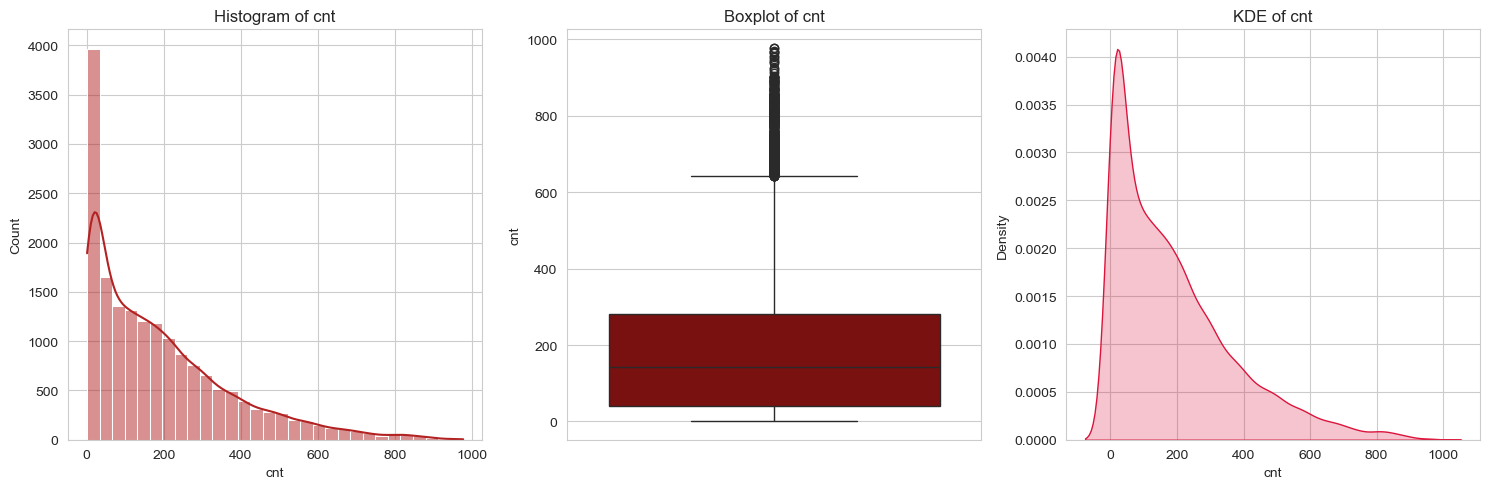

In [25]:
plt.figure(figsize=(15,5))
# Histogram
plt.subplot(1,3,1)
sns.histplot(df['cnt'], bins=30, kde=True, color="#B22222")
plt.title("Histogram of cnt", fontsize=12)
# Boxplot
plt.subplot(1,3,2)
sns.boxplot(y=df['cnt'], color="#8B0000")
plt.title("Boxplot of cnt", fontsize=12)
# KDE
plt.subplot(1,3,3)
sns.kdeplot(df['cnt'], fill=True, color="#DC143C")
plt.title("KDE of cnt", fontsize=12)

plt.tight_layout()
plt.show()

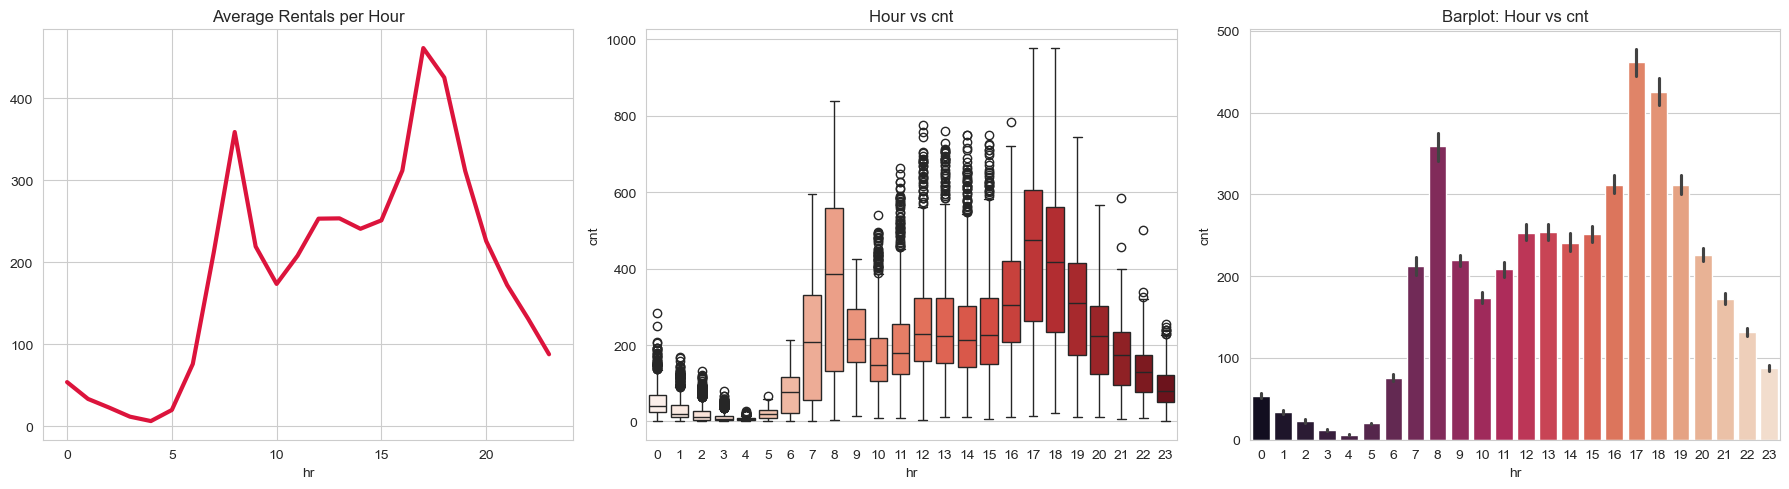

In [26]:
plt.figure(figsize=(18,5))
hour_avg = df.groupby('hr')['cnt'].mean()
# Lineplot
plt.subplot(1,3,1)
sns.lineplot(x=hour_avg.index, y=hour_avg.values, color="#DC143C", linewidth=3)
plt.title("Average Rentals per Hour")
# Boxplot
plt.subplot(1,3,2)
sns.boxplot(x='hr', y='cnt', data=df, palette="Reds")
plt.title("Hour vs cnt")
# Barplot
plt.subplot(1,3,3)
sns.barplot(x='hr', y='cnt', data=df, palette="rocket")
plt.title("Barplot: Hour vs cnt")
plt.tight_layout()
plt.show()

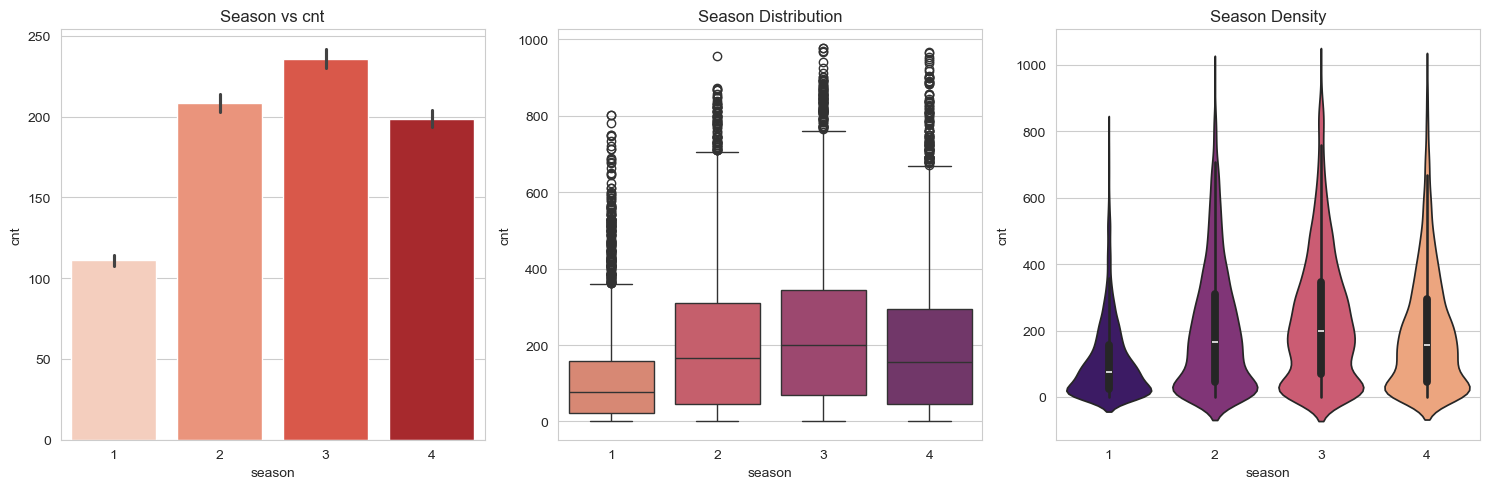

In [27]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.barplot(x='season', y='cnt', data=df, palette="Reds")
plt.title("Season vs cnt")
plt.subplot(1,3,2)
sns.boxplot(x='season', y='cnt', data=df, palette="flare")
plt.title("Season Distribution")
plt.subplot(1,3,3)
sns.violinplot(x='season', y='cnt', data=df, palette="magma")
plt.title("Season Density")

plt.tight_layout()
plt.show()

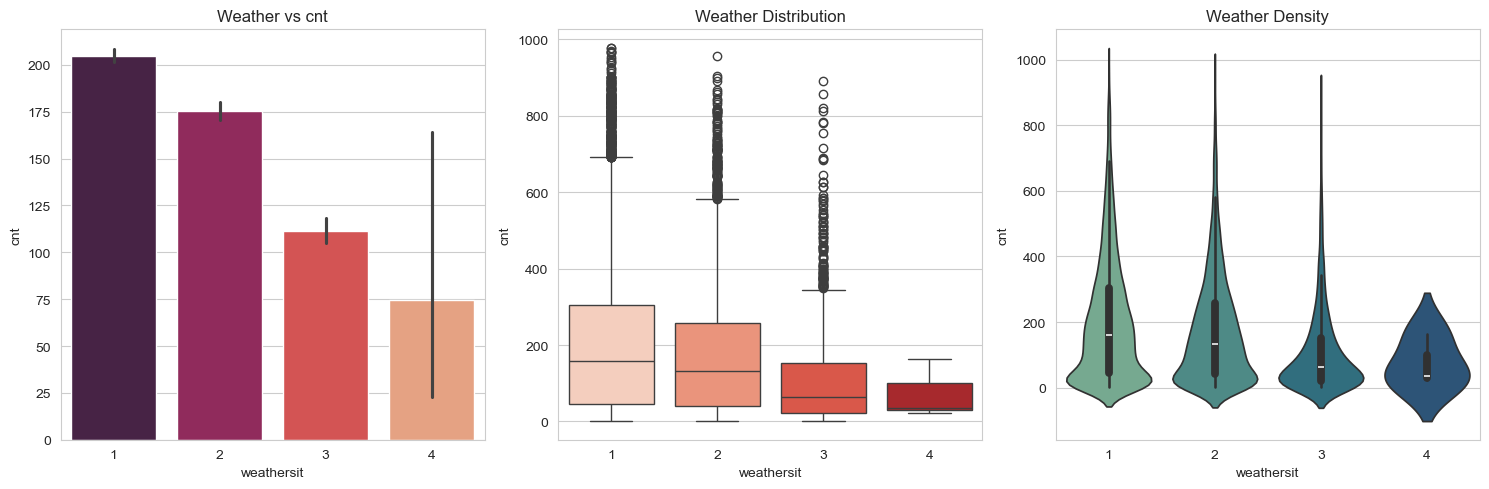

In [28]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.barplot(x='weathersit', y='cnt', data=df, palette="rocket")
plt.title("Weather vs cnt")
plt.subplot(1,3,2)
sns.boxplot(x='weathersit', y='cnt', data=df, palette="Reds")
plt.title("Weather Distribution")
plt.subplot(1,3,3)
sns.violinplot(x='weathersit', y='cnt', data=df, palette="crest")
plt.title("Weather Density")
plt.tight_layout()
plt.show()

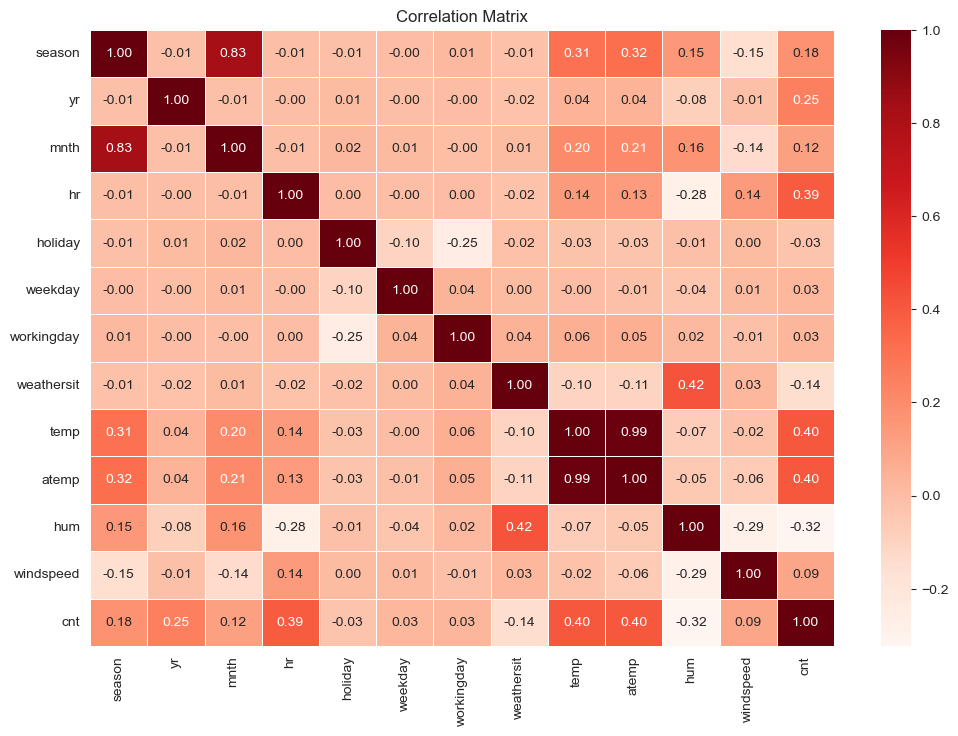

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Reds",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

### Cyclic Encoding



In [30]:
# Cyclical encoding applied because hr, mnth, weekday are circular variables that repeats after a fixed interval creating problems in linear models (e.g., 23 and 0 hours are close in reality but far numerically) 

In [31]:
# Copy dataset
df_model = df.copy()
# Hour encoding (0–23)
df_model['hr_sin'] = np.sin(2 * np.pi * df_model['hr'] / 24)
df_model['hr_cos'] = np.cos(2 * np.pi * df_model['hr'] / 24)
# Month encoding (1–12)
df_model['mnth_sin'] = np.sin(2 * np.pi * df_model['mnth'] / 12)
df_model['mnth_cos'] = np.cos(2 * np.pi * df_model['mnth'] / 12)
# Weekday encoding (0–6)
df_model['weekday_sin'] = np.sin(2 * np.pi * df_model['weekday'] / 7)
df_model['weekday_cos'] = np.cos(2 * np.pi * df_model['weekday'] / 7)

In [32]:
df_model.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,hr_sin,hr_cos,mnth_sin,mnth_cos,weekday_sin,weekday_cos
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,0.000000,1.000000,0.5,0.866025,-0.781831,0.62349
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,0.258819,0.965926,0.5,0.866025,-0.781831,0.62349
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,0.500000,0.866025,0.5,0.866025,-0.781831,0.62349
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,0.707107,0.707107,0.5,0.866025,-0.781831,0.62349
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,0.866025,0.500000,0.5,0.866025,-0.781831,0.62349


In [33]:
# Drop original cyclical columns
df_model = df_model.drop(['hr', 'mnth', 'weekday'], axis=1)

In [34]:
df_model.head()

,dteday,season,yr,holiday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,hr_sin,hr_cos,mnth_sin,mnth_cos,weekday_sin,weekday_cos
0,2011-01-01,1,0,0,0,1,0.24,0.2879,0.81,0.0,16,0.000000,1.000000,0.5,0.866025,-0.781831,0.62349
1,2011-01-01,1,0,0,0,1,0.22,0.2727,0.80,0.0,40,0.258819,0.965926,0.5,0.866025,-0.781831,0.62349
2,2011-01-01,1,0,0,0,1,0.22,0.2727,0.80,0.0,32,0.500000,0.866025,0.5,0.866025,-0.781831,0.62349
3,2011-01-01,1,0,0,0,1,0.24,0.2879,0.75,0.0,13,0.707107,0.707107,0.5,0.866025,-0.781831,0.62349
4,2011-01-01,1,0,0,0,1,0.24,0.2879,0.75,0.0,1,0.866025,0.500000,0.5,0.866025,-0.781831,0.62349


In [35]:
X = df_model.drop('cnt', axis=1)
y = df_model['cnt']

# Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling

In [37]:
X_train.dtypes

dteday         datetime64[ns]
season                  int64
yr                      int64
holiday                 int64
workingday              int64
weathersit              int64
temp                  float64
atemp                 float64
hum                   float64
windspeed             float64
hr_sin                float64
hr_cos                float64
mnth_sin              float64
mnth_cos              float64
weekday_sin           float64
weekday_cos           float64
dtype: object

In [38]:
X_train['dteday'] = X_train['dteday'].map(pd.Timestamp.toordinal)
X_test['dteday'] = X_test['dteday'].map(pd.Timestamp.toordinal)

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building -

### Linear Regression

In [40]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

### Ridge Regression

In [41]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

### Random Forest

In [42]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

### Gradient Boosting

In [43]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.1, random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

### KNN

In [44]:
from sklearn.neighbors import KNeighborsRegressor
# Initialize KNN Regressor
# n_neighbors can be tuned; start with 5
knn = KNeighborsRegressor(n_neighbors=5)
# Fit KNN (use scaled data for KNN)
knn.fit(X_train_scaled, y_train)
# Predict
y_pred_knn = knn.predict(X_test_scaled)

# Model Evaluation

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")
    print("-"*40)
    return mae, rmse, r2

In [46]:
results = {}
results['Linear Regression'] = evaluate_model(y_test, y_pred_lr, "Linear Regression")
results['Ridge Regression'] = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
results['Random Forest'] = evaluate_model(y_test, y_pred_rf, "Random Forest")
results['Gradient Boosting'] = evaluate_model(y_test, y_pred_gb, "Gradient Boosting")
results['KNN Regression'] = evaluate_model(y_test, y_pred_knn, "KNN Regression")

Linear Regression
MAE  : 91.90
RMSE : 125.60
R2   : 0.5018
----------------------------------------
Ridge Regression
MAE  : 91.89
RMSE : 125.60
R2   : 0.5018
----------------------------------------
Random Forest
MAE  : 23.92
RMSE : 40.25
R2   : 0.9488
----------------------------------------
Gradient Boosting
MAE  : 38.19
RMSE : 54.63
R2   : 0.9057
----------------------------------------
KNN Regression
MAE  : 53.52
RMSE : 83.01
R2   : 0.7824
----------------------------------------


In [47]:
results_df = pd.DataFrame(results, index=['MAE', 'RMSE', 'R2']).T
results_df.sort_values(by='RMSE')

,MAE,RMSE,R2
Random Forest,23.915841,40.253168,0.948830
Gradient Boosting,38.190691,54.631130,0.905747
KNN Regression,53.521001,83.014802,0.782366
Linear Regression,91.895641,125.600733,0.501805
Ridge Regression,91.894890,125.600946,0.501803


# Hyperparameter Tuning

In [48]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### Linear Regression

In [49]:
lr = LinearRegression()
param_dist_lr = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}
lr_random = RandomizedSearchCV(
    lr,
    param_distributions=param_dist_lr,
    n_iter=4,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
lr_random.fit(X_train_scaled, y_train)
best_lr = lr_random.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
evaluate_model(y_test, y_pred_lr, "Linear Regression (Tuned)")

Linear Regression (Tuned)
MAE  : 91.90
RMSE : 125.60
R2   : 0.5018
----------------------------------------


(91.8956405209365, np.float64(125.60073288835103), 0.501805173649257)

#### Ridge Regression

In [50]:
ridge = Ridge()
param_dist_ridge = {
    'alpha': np.logspace(-4, 4, 100),
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}
ridge_random = RandomizedSearchCV(
    ridge,
    param_distributions=param_dist_ridge,
    n_iter=30,   # FAST but effective
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
ridge_random.fit(X_train_scaled, y_train)
best_ridge = ridge_random.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)
evaluate_model(y_test, y_pred_ridge, "Ridge (Tuned)")

Ridge (Tuned)
MAE  : 91.88
RMSE : 125.61
R2   : 0.5018
----------------------------------------


(91.87734186582725, np.float64(125.60606566975095), 0.5017628678371314)

#### KNN

In [51]:
knn = KNeighborsRegressor()

param_dist_knn = {
    'n_neighbors': np.arange(3, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
knn_random = RandomizedSearchCV(
    knn,
    param_distributions=param_dist_knn,
    n_iter=30,   # FAST search
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
knn_random.fit(X_train_scaled, y_train)
best_knn = knn_random.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
evaluate_model(y_test, y_pred_knn, "KNN (Tuned)")

KNN (Tuned)
MAE  : 51.43
RMSE : 79.52
R2   : 0.8003
----------------------------------------


(51.43399195746193, np.float64(79.52140836318496), 0.800297734304688)

#### Gradient Boosting

In [52]:
param_dist_gb = {
    'n_estimators': np.arange(100, 501, 50),
    'learning_rate': np.linspace(0.01, 0.2, 20),
    'max_depth': np.arange(3, 8),
    'min_samples_split': np.arange(2, 11),
    'subsample': np.linspace(0.7, 1.0, 10)
}

In [53]:
gb_random = RandomizedSearchCV(
    gb,
    param_distributions=param_dist_gb,
    n_iter=25,        # between 20–30 for speed
    cv=3,             # reduce from 5 to 3 for faster run
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
gb_random.fit(X_train, y_train)
print("Best Parameters:", gb_random.best_params_)
print("Best CV RMSE:", -gb_random.best_score_)

Best Parameters: {'subsample': np.float64(0.8666666666666667), 'n_estimators': np.int64(300), 'min_samples_split': np.int64(6), 'max_depth': np.int64(7), 'learning_rate': np.float64(0.04)}
Best CV RMSE: 39.34033250586984


In [54]:
best_gb = gb_random.best_estimator_
y_pred_gb = best_gb.predict(X_test)
evaluate_model(y_test, y_pred_gb, "Gradient Boosting (Tuned)")

Gradient Boosting (Tuned)
MAE  : 21.78
RMSE : 35.82
R2   : 0.9595
----------------------------------------


(21.78284858408261, np.float64(35.8238627672303), 0.9594715783120803)

#### Random Forest

In [55]:
# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,              # keep small for faster tuning
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)
# Fit model
rf_random.fit(X_train, y_train)
# Best model
best_rf = rf_random.best_estimator_
print("Best Parameters:", rf_random.best_params_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [56]:
y_pred_rf = best_rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
print("Random Forest (Tuned) Performance:")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R2   :", round(r2, 4))

Random Forest (Tuned) Performance:
MAE  : 27.75
RMSE : 41.94
R2   : 0.9444


##### However, the tuned model did not improve performance compared to the default Random Forest model.

# Model Comparison

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Train ALL models properly
# -----------------------------
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)
rf_tuned.fit(X_train, y_train)

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

gb_tuned = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
gb_tuned.fit(X_train, y_train)
# Compare Models
# -----------------------------
models = {
    "Linear Regression": (lr, X_test_scaled),
    "Ridge Regression": (ridge, X_test_scaled),
    "KNN": (knn, X_test_scaled),
    "Random Forest (Default)": (rf, X_test),
    "Random Forest (Tuned)": (rf_tuned, X_test),
    "Gradient Boosting (Default)": (gb, X_test),
    "Gradient Boosting (Tuned)": (gb_tuned, X_test)
}

results = []

for name, (model, X_test_used) in models.items():
    y_pred = model.predict(X_test_used)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df = results_df.sort_values(by="R2", ascending=False)

print(results_df)

                         Model        MAE        RMSE        R2
3      Random Forest (Default)  24.101884   40.460336  0.948302
4        Random Forest (Tuned)  24.034074   40.493555  0.948217
6    Gradient Boosting (Tuned)  27.996244   42.724749  0.942353
5  Gradient Boosting (Default)  42.782341   60.732375  0.883519
2                          KNN  53.521001   83.014802  0.782366
0            Linear Regression  91.895641  125.600733  0.501805
1             Ridge Regression  91.894890  125.600946  0.501803


## The best performing model for this bike rental demand prediction project was--
### Random Forest :
#### Random Forest(without hyperparameter tuned)achieved the highest R² score (0.9483) and the lowest RMSE (40.46), making it the best-performing model for bike rental demand prediction. Hyperparameter tuning did not significantly improve Random Forest performance. Although tuned Gradient Boosting performed well, it remained slightly inferior to Random Forest in predictive accuracy.

# Challenges faced --

- In the bike rental demand prediction project, time-based features such as hour, month, and day of the week exhibit cyclical behavior. 
- For example, hour 23 (11 PM) is immediately followed by hour 0 (12 AM), meaning the data is circular rather than linear.
- Proper encoding of these cyclical variables was necessary to preserve their inherent periodic nature.
- Standard numerical encoding treats values as linearly increasing. However, cyclical features follow a repeating pattern.

#### Understanding Circular Relationships
- One major challenge was recognizing that features like:
  - Hour (0–23)
  - Month (1–12)
  - Day of week (0–6)
- are not ordinal in a linear sense but circular. Initially, treating them as integers caused distorted distance relationships

#### If cyclical encoding were not applied:
- Artificial Discontinuity
  - The model would treat cycle boundaries as far apart.
  - Example:
  - December (12) and January (1) would appear numerically distant.
- Poor Model Learning
  - Models would struggle to capture:
  - Night vs early morning similarity
  - Seasonal transitions
  - Weekly rental patterns